In [30]:
import os
if not os.path.exists("git/main.py"):
    !rm -rfd sample_data
    !rm -rfd git
    !git clone --single-branch --branch Util https://github.com/DemirDorukDilek/DDoP git


import importlib
import sys
top_level_container_dir = "git/"
if top_level_container_dir not in sys.path:
    sys.path.insert(0, top_level_container_dir)

import Utils,DDoPnDm,IRIS,RRTstar,Ucorridor
importlib.reload(Utils)
importlib.reload(DDoPnDm)
importlib.reload(IRIS)
importlib.reload(RRTstar)
importlib.reload(Ucorridor)
from Utils import visualize_trajectory_2d,polygon_to_polyhedron,visualize_state,visualize_results_2d,plot_corridors,plot_rrt
from DDoPnDm import DDoPnD
from IRIS import greedy_corridor_generation, verify_corridors
from RRTstar import rrt_star
from Ucorridor import ConvexObstacle

import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.optimize import minimize
import scipy.special

waypoints = [
    np.array((0, 0)), # q₀: Başlangıç
    np.array((1.5, 0.5)), # q₁: İlk dönüş
    np.array((2.5, 1.5)), # q₂: Engeli geç
    np.array((3.0, -1.5)), # q₃: İkinci dönüş
    np.array((5.25, 1.0)), # q₄: Bitiş
]

# Polyhedra: Her piece için güvenli bölge (CCW sıralı köşeler)
polygons = [
    # P₀: Başlangıç bölgesi (geniş alan)
    [
        (-0.5, -0.2),
        (1.6, 0.4),
        (1.6, 0.6),
        (-0.5, 0.2)
    ],

    # P₁: Dar geçit (engelin solundan)
    [
        (1.4, 0.4),
        (3.0, 1),
        (3.0, 2.5),
        (1.4, 0.6),
    ],

    # P₂: Engel üstü bölge
    [
        (2.4, 1.4),
        (3.0, -2),
        (4.0, -1.5),
        (2.4, 1.8)
    ],

    # P₃: Bitiş bölgesi
    [
        (2.9, -2),
        (5.5, -0.5),
        (5.5, 1.5),
        (2.9, -1.5)
    ],
]

Cloning into 'git'...
remote: Enumerating objects: 132, done.
remote: Counting objects: 100% (32/32), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 132 (delta 21), reused 9 (delta 9), pack-reused 100 (from 1)
Receiving objects: 100% (132/132), 3.08 MiB | 23.37 MiB/s, done.
Resolving deltas: 100% (60/60), done.


[(np.int64(9), np.int64(0)), (np.int64(11), np.int64(-2)), (np.int64(12), np.int64(-1)), (np.int64(10), np.int64(1))]


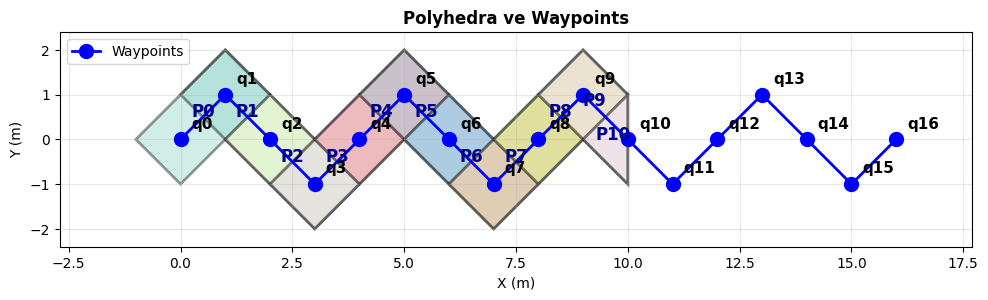

In [2]:
waypoints = [
    np.array((0, 0)),
    np.array((1, 1)),
    np.array((2, 0)),
    np.array((3, -1)),
    np.array((4, 0)),
    np.array((5, 1)),
    np.array((6, 0)),
    np.array((7, -1)),
    np.array((8, 0)),
    np.array((9, 1)),
    np.array((10, 0)),
    np.array((11, -1)),
    np.array((12, 0)),
    np.array((13, 1)),
    np.array((14, 0)),
    np.array((15, -1)),
    np.array((16, 0)),
]



d = 1
dd = True
polygons = []
for i in range(len(waypoints)-1):
    w0 = waypoints[i]
    w1 = waypoints[i+1]
    if dd:
        polygons.append([(w0[0],w0[1]-1),(w1[0]+1,w1[1]),(w1[0],w1[1]+1),(w0[0]-1,w0[1])])
    else:
        polygons.append([(w0[0]-1,w0[1]),(w1[0],w1[1]-1),(w1[0]+1,w1[1]),(w0[0],w0[1]+1)])
    if d == 1:
        dd = not dd
        d = -1
    d+=1
print(polygons[10])
opt_waypoint = list(map(np.array,waypoints))
polyhedras = list(map(polygon_to_polyhedron,polygons))
visualize_state(polyhedras,opt_waypoint)

In [26]:
def check_piece_feasibility(opt, piece_idx, hpoly, v_max, a_max, num_samples=50):
    T = opt.Ts[piece_idx]
    A, b = hpoly
    S2 = 2 * opt.S

    c = np.array([subopt.Abs[piece_idx] @ subopt.dstar[2*opt.S*piece_idx : 2*opt.S*(piece_idx+1)].flatten() for subopt in opt.opt])

    dc = c[:, 1:] * np.arange(1, S2)
    ddc = dc[:, 1:] * np.arange(1, S2-1)

    t_powers = np.power(np.linspace(0, T, num_samples)[:, None], np.arange(S2))

    pos = t_powers @ c.T
    vel_mag = np.linalg.norm(t_powers[:,:S2-1] @ dc.T, axis=1)
    acc_mag = np.linalg.norm(t_powers[:,:S2-2] @ ddc.T, axis=1)

    slack = b - (A @ pos.T).T
    min_slack_per_sample = np.min(slack, axis=1)

    if np.any(slack < 0):
        return False,0

    if np.max(vel_mag) > v_max:
        return False,1

    if np.max(acc_mag) > a_max:
        return False,2

    return True,-1


def check_all_pieces(opt, hploys, v_max, a_max, num_samples=50):
    violations = []
    for m in range(opt.M):
        poly_ok, type_ = check_piece_feasibility(opt, m, hploys[m], v_max, a_max, num_samples)

        if not poly_ok:
            violations.append((m,type_))

    return violations


def clip_hpoly(A, b, plane_point, plane_normal):
    plane_normal = np.array(plane_normal, dtype=float)
    plane_point = np.array(plane_point, dtype=float)
    plane_normal = plane_normal / np.linalg.norm(plane_normal)

    a_new = -plane_normal.reshape(1, -1)
    b_new = np.array([-plane_normal @ plane_point])

    A_clipped = np.vstack([A, a_new])
    b_clipped = np.concatenate([b, b_new])

    return A_clipped, b_clipped


def split_hpoly(hpoly, q_prev, q_next, margin=0.1):
    A,b = hpoly

    q_prev = np.array(q_prev, dtype=float)
    q_next = np.array(q_next, dtype=float)

    midpoint = (q_prev + q_next) / 2
    direction = q_next - q_prev
    length = np.linalg.norm(direction)
    direction = direction / length

    plane0_point = midpoint - margin * direction
    plane1_point = midpoint + margin * direction

    A0, b0 = clip_hpoly(A, b, plane0_point, direction)
    A1, b1 = clip_hpoly(A, b, plane1_point, -direction)

    return (A0, b0), (A1, b1), midpoint




def optimize_with_split(Ts_init, waypoints_init, hpolys_init ,max_iterations=5):

    Ts = Ts_init.copy()
    waypoints = waypoints_init.copy()
    hpolys = hpolys_init.copy()
    rho_v = [128.0]*len(Ts)
    rho_a = [128.0]*len(Ts)
    pakka = [1.0]*len(Ts)
    last_split = -1
    for iteration in range(max_iterations):

        opt_waypoint = list(map(np.array,waypoints))
        rho_v_arr = np.array(rho_v)
        rho_a_arr = np.array(rho_a)
        pakka_arr = np.array(pakka)

        opt = DDoPnD([1.0]*(len(waypoints)-1),opt_waypoint,hpolys,32.0,rho_v_arr,rho_a_arr,pakka_arr,False,False,3)
        T_opt, wp_opt, cost = opt.run()
        if "opt" in locals():
            pass
            # visualize_results_2d(opt, hpolys, wp_opt, [])
        # print(T_opt, wp_opt, cost)

        waypoints = [wp_opt[i] for i in range(len(wp_opt))]
        Ts = list(T_opt)

        violations = check_all_pieces(opt, hpolys, opt.v_max, opt.a_max)[::-1]
        if len(violations) == 0:return opt, Ts, waypoints, hpolys

        if len(violations) > 1 and violations[0][0] == last_split:
            piece_idx,vaolation_type = violations[1]
        else:
            piece_idx,vaolation_type = violations[0]
        last_split = piece_idx
        penalty_list = None

        print(piece_idx,vaolation_type)

        q_prev = waypoints[piece_idx]
        q_next = waypoints[piece_idx + 1]

        poly_0, poly_1,new_waypoint = split_hpoly(hpolys[piece_idx], q_prev, q_next, 0.5)

        waypoints.insert(piece_idx + 1, new_waypoint)
        Ts[piece_idx] = Ts[piece_idx] / 2
        Ts.insert(piece_idx + 1, Ts[piece_idx] / 2)

        if vaolation_type == 0:
            pakka[piece_idx] = pakka[piece_idx]*1.5
            pakka.insert(piece_idx + 1, pakka[piece_idx])
            rho_v.insert(piece_idx + 1,128.0)
            rho_a.insert(piece_idx + 1,128.0)
        elif vaolation_type == 1:
            rho_v[piece_idx] = rho_v[piece_idx]*1.5
            rho_v.insert(piece_idx + 1, rho_v[piece_idx])
            pakka.insert(piece_idx + 1,1.0)
            rho_a.insert(piece_idx + 1,128.0)
        elif vaolation_type == 2:
            rho_a[piece_idx] = rho_a[piece_idx]*1.5
            rho_a.insert(piece_idx + 1, rho_a[piece_idx])
            pakka.insert(piece_idx + 1,1.0)
            rho_v.insert(piece_idx + 1,128.0)

        hpolys[piece_idx] = poly_1
        hpolys.insert(piece_idx + 1, poly_0)


    return opt, Ts, waypoints, hpolys

polyhedras = list(map(polygon_to_polyhedron,polygons))
optimize_with_split([1.0]*(len(waypoints)-1),waypoints,polyhedras,10)
print()


2 0
3 0
4 0
5 0
6 0
7 0
8 0
9 0
10 0
11 0



Step 1: RRT* Time: 35.32847857475281
Step 2: IRIS Corridors Time: 0.7738687992095947
Verification:    OK
Step 3: Optimization Time:1.4566965103149414
Total: 37.56026363372803


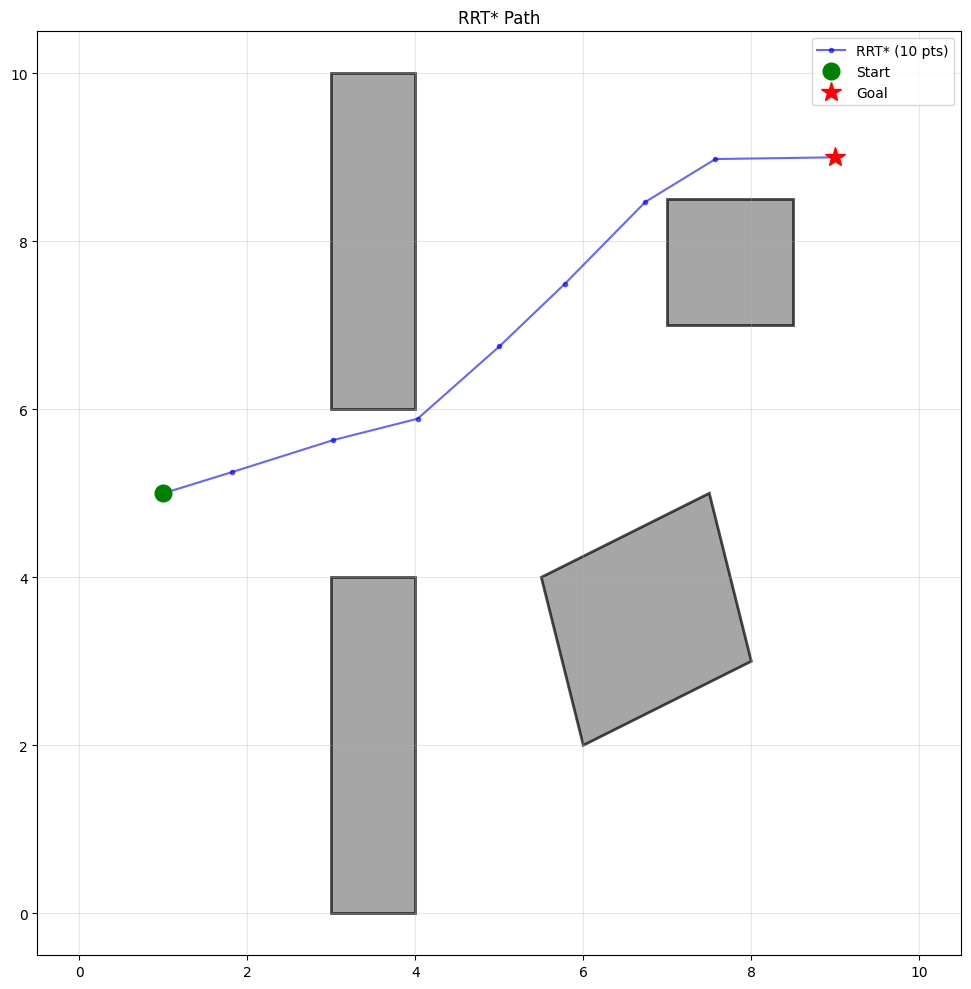

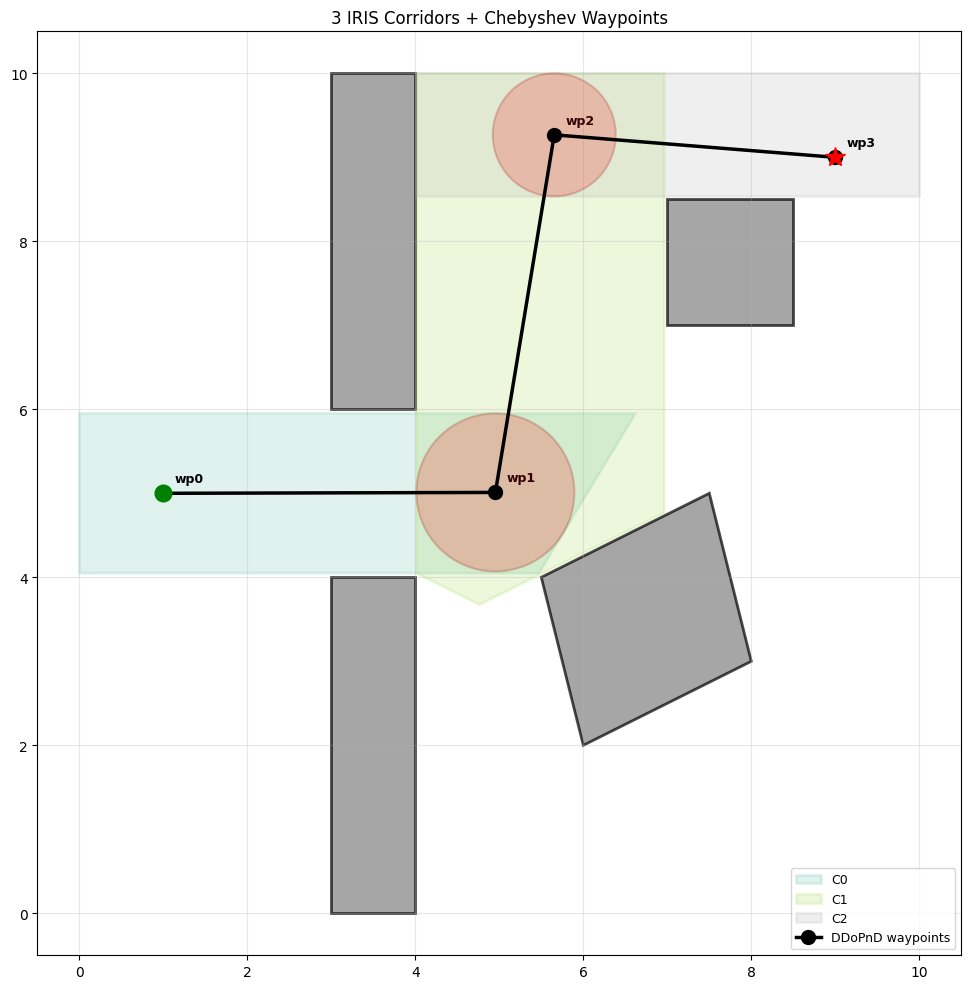

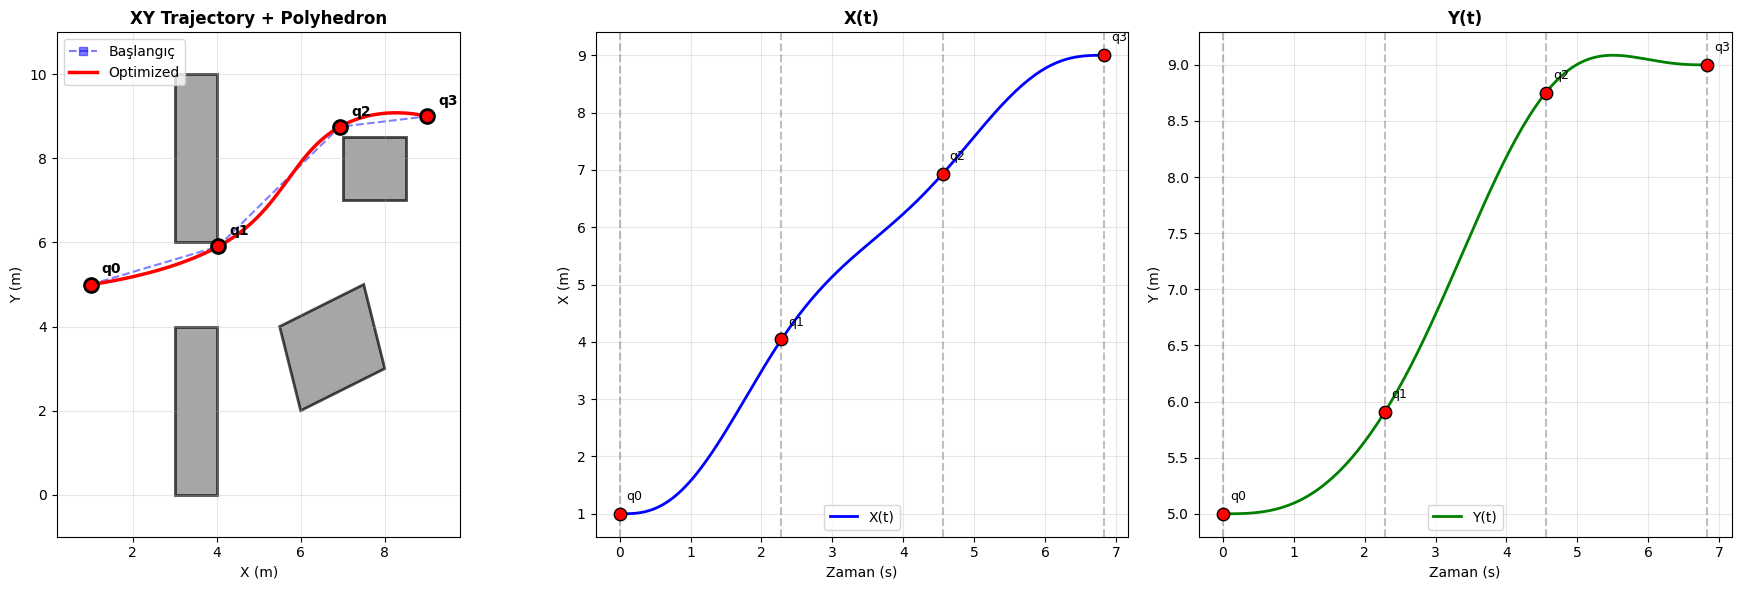

In [33]:
import time
np.random.seed(42)
bounds = (np.array([0.,0.]), np.array([10.,10.]))

obstacles = [
    ConvexObstacle(np.array([[3.,0.],[4.,0.],[4.,4.],[3.,4.]])),
    ConvexObstacle(np.array([[3.,6.],[4.,6.],[4.,10.],[3.,10.]])),
    ConvexObstacle(np.array([[6.,2.],[8.,3.],[7.5,5.],[5.5,4.]])),
    ConvexObstacle(np.array([[7.,7.],[8.5,7.],[8.5,8.5],[7.,8.5]])),
]

start, goal = np.array([1.,5.]), np.array([9.,9.])

print("Step 1: RRT* Time: ", end="")
rrt_time = time.time()
path = rrt_star(start, goal, obstacles, bounds,max_iter=3000, step_size=0.5, goal_bias=0.15, goal_tol=0.5, safety_margin=0.1)
print(time.time()-rrt_time)
if path is None:
    print("  RRT* failed!")
    exit(3)

print("Step 2: IRIS Corridors Time: ", end="")
iris_time = time.time()
iris_result = greedy_corridor_generation(path, obstacles, bounds)
print(time.time()-iris_time)
if iris_result is None:
    print("  Corridor generation failed!")
    exit(2)
corridors, waypoints, radii = iris_result
print("Verification:", end="")
verify_corridors(corridors, radii)

hpolys = list(map(lambda x:(x.hpoly.A,x.hpoly.b),corridors))
print("Step 3: Optimization Time:", end="")
ddop_time = time.time()
opt, Ts, op_wp, opt_hpolys = optimize_with_split([1.0]*(len(waypoints)-1),waypoints,hpolys,10)
print(time.time()-ddop_time)
print("Total:", time.time()-rrt_time)
plot_rrt(path, obstacles, start, goal, bounds, save_path='rrt.png')
plot_corridors(corridors, waypoints, radii, obstacles, start, goal, bounds, save_path='corridors.png')
visualize_results_2d(opt, opt_hpolys, op_wp, bounds, obstacles, save_path="results.png")

In [29]:
!rm git/main.py